# NeuroGolf 2026 EDA

This notebook reviews the ARC-style NeuroGolf task data before modeling. It is designed to run inside Kaggle, where the competition or companion public data is attached under `/kaggle/input`. The analysis focuses on task coverage, pair counts, grid geometry, color-token behavior, visual inspection, and first-pass solver buckets.

# 1. Setup and Data Loading

## 1.1 Setup and Display Defaults

The runtime assumptions are intentionally Kaggle-native: import common notebook libraries, standardize plot styling, and define the ARC grid palette used for puzzle rendering.

In [1]:
from __future__ import annotations

import json
import math
import os
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import BoundaryNorm, ListedColormap

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

PLOT_CMAP = "viridis"
plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ARC_COLORS = [
    "#000000",  # 0 black
    "#0074D9",  # 1 blue
    "#FF4136",  # 2 red
    "#2ECC40",  # 3 green
    "#FFDC00",  # 4 yellow
    "#AAAAAA",  # 5 gray
    "#F012BE",  # 6 magenta
    "#FF851B",  # 7 orange
    "#7FDBFF",  # 8 light blue
    "#870C25",  # 9 maroon
]
ARC_CMAP = ListedColormap(ARC_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, 10.5, 1), ARC_CMAP.N)


def insight(title: str, bullets: list[str]) -> None:
    clean_bullets = [b for b in bullets if b]
    if clean_bullets:
        display(Markdown("### " + title + "\n" + "\n".join(f"- {b}" for b in clean_bullets)))


## 1.2 Data Discovery

The input scanner avoids hard-coded Kaggle dataset names. It searches `/kaggle/input` first and then falls back to common local folders for occasional offline development.

In [2]:
KAGGLE_INPUT = Path("/kaggle/input")
LOCAL_CANDIDATES = [Path("../input"), Path("input"), Path("data"), Path("../data")]


def candidate_roots() -> list[Path]:
    roots: list[Path] = []
    if KAGGLE_INPUT.exists():
        roots.extend([p for p in KAGGLE_INPUT.iterdir() if p.is_dir()])
        roots.append(KAGGLE_INPUT)
    roots.extend([p for p in LOCAL_CANDIDATES if p.exists()])
    return roots


def find_json_files() -> list[Path]:
    files: list[Path] = []
    for root in candidate_roots():
        files.extend(root.rglob("*.json"))
    return sorted(set(files))


json_files = find_json_files()
print(f"Found {len(json_files):,} JSON files")
for path in json_files[:25]:
    print(path)
if len(json_files) > 25:
    print(f"... {len(json_files) - 25:,} more")

insight(
    "Data Discovery Insights",
    [
        f"Discovered {len(json_files):,} JSON files across {len(candidate_roots()):,} candidate input roots.",
        "If this count is zero on Kaggle, attach the NeuroGolf competition data or the companion public task dataset before continuing.",
        "The first printed paths should confirm whether the notebook is reading per-task files or a combined task dictionary.",
    ],
)


Found 800 JSON files
/kaggle/input/competitions/neurogolf-2026/task001.json
/kaggle/input/competitions/neurogolf-2026/task002.json
/kaggle/input/competitions/neurogolf-2026/task003.json
/kaggle/input/competitions/neurogolf-2026/task004.json
/kaggle/input/competitions/neurogolf-2026/task005.json
/kaggle/input/competitions/neurogolf-2026/task006.json
/kaggle/input/competitions/neurogolf-2026/task007.json
/kaggle/input/competitions/neurogolf-2026/task008.json
/kaggle/input/competitions/neurogolf-2026/task009.json
/kaggle/input/competitions/neurogolf-2026/task010.json
/kaggle/input/competitions/neurogolf-2026/task011.json
/kaggle/input/competitions/neurogolf-2026/task012.json
/kaggle/input/competitions/neurogolf-2026/task013.json
/kaggle/input/competitions/neurogolf-2026/task014.json
/kaggle/input/competitions/neurogolf-2026/task015.json
/kaggle/input/competitions/neurogolf-2026/task016.json
/kaggle/input/competitions/neurogolf-2026/task017.json
/kaggle/input/competitions/neurogolf-2026/ta

### Data Discovery Insights
- Discovered 800 JSON files across 3 candidate input roots.
- If this count is zero on Kaggle, attach the NeuroGolf competition data or the companion public task dataset before continuing.
- The first printed paths should confirm whether the notebook is reading per-task files or a combined task dictionary.

## 1.3 Data Loading

NeuroGolf public data can appear as one JSON file per task or as a combined dictionary. This loader normalizes both layouts into a single `tasks` mapping keyed by task id.

In [3]:
def is_task_payload(obj: Any) -> bool:
    return isinstance(obj, dict) and "train" in obj and "test" in obj


def normalize_task_id(path: Path, key: str | None = None) -> str:
    if key:
        key = str(key)
        return key[:-5] if key.endswith(".json") else key
    return path.stem


def load_tasks(files: list[Path]) -> dict[str, dict[str, Any]]:
    tasks: dict[str, dict[str, Any]] = {}
    for path in files:
        try:
            with path.open("r") as f:
                obj = json.load(f)
        except Exception as exc:
            print(f"Skipping {path}: {exc}")
            continue

        if is_task_payload(obj):
            tasks[normalize_task_id(path)] = obj
        elif isinstance(obj, dict):
            for key, value in obj.items():
                if is_task_payload(value):
                    tasks[normalize_task_id(path, key)] = value
        elif isinstance(obj, list):
            for idx, value in enumerate(obj, start=1):
                if is_task_payload(value):
                    tasks[f"task{idx:03d}"] = value
    return dict(sorted(tasks.items()))


tasks = load_tasks(json_files)
print(f"Loaded {len(tasks):,} tasks")
display(list(tasks)[:10])

insight(
    "Data Loading Insights",
    [
        f"Loaded {len(tasks):,} normalized ARC-style tasks.",
        "The first ids above are the ids later expected by solver and ONNX-export notebooks.",
        "A large gap between JSON files found and tasks loaded usually means some JSON files are metadata rather than ARC task payloads.",
    ],
)


Loaded 400 tasks


['task001',
 'task002',
 'task003',
 'task004',
 'task005',
 'task006',
 'task007',
 'task008',
 'task009',
 'task010']

### Data Loading Insights
- Loaded 400 normalized ARC-style tasks.
- The first ids above are the ids later expected by solver and ONNX-export notebooks.
- A large gap between JSON files found and tasks loaded usually means some JSON files are metadata rather than ARC task payloads.

# 2. Dataset Overview

## 2.1 Task Inventory

The inventory converts nested train/test examples into task-level features: pair counts, grid sizes, observed color sets, and whether training outputs change shape.

In [4]:
def grid_shape(grid: list[list[int]]) -> tuple[int, int]:
    arr = np.asarray(grid)
    return tuple(arr.shape) if arr.ndim == 2 else (0, 0)


def grid_colors(grid: list[list[int]]) -> set[int]:
    arr = np.asarray(grid)
    return set(map(int, np.unique(arr))) if arr.size else set()


def task_summary(task_id: str, task: dict[str, Any]) -> dict[str, Any]:
    train = task.get("train", [])
    test = task.get("test", [])
    pairs = train + test

    input_shapes = [grid_shape(pair["input"]) for pair in pairs if "input" in pair]
    output_shapes = [grid_shape(pair["output"]) for pair in pairs if "output" in pair]
    train_output_shapes = [grid_shape(pair["output"]) for pair in train if "output" in pair]

    input_colors = set().union(*(grid_colors(pair["input"]) for pair in pairs if "input" in pair)) if pairs else set()
    output_colors = set().union(*(grid_colors(pair["output"]) for pair in pairs if "output" in pair)) if output_shapes else set()

    train_shape_changes = [
        grid_shape(pair["input"]) != grid_shape(pair["output"])
        for pair in train
        if "input" in pair and "output" in pair
    ]

    return {
        "task_id": task_id,
        "n_train": len(train),
        "n_test": len(test),
        "has_test_outputs": all("output" in pair for pair in test) if test else False,
        "input_shapes": sorted(set(input_shapes)),
        "output_shapes": sorted(set(output_shapes)),
        "train_output_shapes": sorted(set(train_output_shapes)),
        "n_input_colors": len(input_colors),
        "n_output_colors": len(output_colors),
        "input_colors": tuple(sorted(input_colors)),
        "output_colors": tuple(sorted(output_colors)),
        "shape_changes_in_train": any(train_shape_changes),
        "max_input_area": max((r * c for r, c in input_shapes), default=0),
        "max_output_area": max((r * c for r, c in output_shapes), default=0),
    }


summary_df = pd.DataFrame([task_summary(task_id, task) for task_id, task in tasks.items()])
display(summary_df.head(10))

if summary_df.empty:
    inventory_bullets = ["No task inventory is available yet because no tasks were loaded."]
else:
    inventory_bullets = [
        f"The inventory contains {len(summary_df):,} tasks with a median of {summary_df['n_train'].median():.1f} training examples and {summary_df['n_test'].median():.1f} test cases per task.",
        f"Training examples show shape changes in {summary_df['shape_changes_in_train'].sum():,} tasks ({summary_df['shape_changes_in_train'].mean():.1%}).",
        f"The median task uses {summary_df['n_input_colors'].median():.1f} unique input colors, with a maximum of {summary_df['n_input_colors'].max():,}.",
    ]
insight("Task Inventory Insights", inventory_bullets)


,task_id,n_train,n_test,has_test_outputs,input_shapes,output_shapes,train_output_shapes,n_input_colors,n_output_colors,input_colors,output_colors,shape_changes_in_train,max_input_area,max_output_area
0,task001,5,1,True,"[(3, 3)]","[(9, 9)]","[(9, 9)]",5,5,"(0, 2, 4, 6, 7)","(0, 2, 4, 6, 7)",True,9,81
1,task002,5,1,True,"[(6, 6), (10, 10), (20, 20)]","[(6, 6), (10, 10), (20, 20)]","[(6, 6), (10, 10), (20, 20)]",2,3,"(0, 3)","(0, 3, 4)",False,400,400
2,task003,3,1,True,"[(6, 3)]","[(9, 3)]","[(9, 3)]",2,2,"(0, 1)","(0, 2)",True,18,27
3,task004,2,1,True,"[(8, 9), (10, 10), (14, 9)]","[(8, 9), (10, 10), (14, 9)]","[(8, 9), (14, 9)]",5,5,"(0, 2, 4, 6, 8)","(0, 2, 4, 6, 8)",False,126,126
4,task005,3,1,True,"[(21, 21)]","[(21, 21)]","[(21, 21)]",8,8,"(0, 1, 2, 3, 4, 5, 6, 8)","(0, 1, 2, 3, 4, 5, 6, 8)",False,441,441
5,task006,3,1,True,"[(3, 7)]","[(3, 3)]","[(3, 3)]",3,2,"(0, 1, 5)","(0, 2)",True,21,9
6,task007,3,1,True,"[(7, 7)]","[(7, 7)]","[(7, 7)]",6,5,"(0, 1, 2, 3, 4, 8)","(1, 2, 3, 4, 8)",False,49,49
7,task008,3,1,True,"[(9, 10), (11, 10), (14, 9)]","[(9, 10), (11, 10), (14, 9)]","[(9, 10), (11, 10), (14, 9)]",3,3,"(0, 2, 8)","(0, 2, 8)",False,126,126
8,task009,3,1,True,"[(20, 20), (23, 23), (26, 26)]","[(20, 20), (23, 23), (26, 26)]","[(20, 20), (23, 23)]",7,7,"(0, 1, 2, 3, 4, 8, 9)","(0, 1, 2, 3, 4, 8, 9)",False,676,676
9,task010,2,1,True,"[(9, 9)]","[(9, 9)]","[(9, 9)]",2,5,"(0, 5)","(0, 1, 2, 3, 4)",False,81,81


### Task Inventory Insights
- The inventory contains 400 tasks with a median of 3.0 training examples and 1.0 test cases per task.
- Training examples show shape changes in 138 tasks (34.5%).
- The median task uses 6.0 unique input colors, with a maximum of 10.

## 2.2 Coverage Checks

The competition submission format expects task ids such as `task001` through `task400`. This check makes missing or non-standard ids visible before downstream solver notebooks rely on them.

In [5]:
print(summary_df.shape)
if summary_df.empty:
    print("No tasks loaded yet. Attach the Kaggle competition/public data and rerun from the top.")
    coverage_bullets = ["Coverage cannot be assessed until task data is attached."]
else:
    display(summary_df.describe(include="all"))

    expected_ids = {f"task{i:03d}" for i in range(1, 401)}
    observed_ids = set(summary_df["task_id"])
    missing_expected = sorted(expected_ids - observed_ids)
    extra_ids = sorted(observed_ids - expected_ids)

    print(f"Expected-style tasks present: {len(expected_ids & observed_ids):,} / 400")
    print(f"Missing expected ids: {missing_expected[:20]}{' ...' if len(missing_expected) > 20 else ''}")
    print(f"Non-standard ids: {extra_ids[:20]}{' ...' if len(extra_ids) > 20 else ''}")

    coverage_bullets = [
        f"Observed {len(expected_ids & observed_ids):,} of the 400 expected-style task ids.",
        f"There are {len(missing_expected):,} missing expected ids and {len(extra_ids):,} non-standard ids.",
        "Resolve naming or attachment issues here before building per-task ONNX submission artifacts.",
    ]
insight("Coverage Insights", coverage_bullets)


(400, 14)


,task_id,n_train,n_test,has_test_outputs,input_shapes,output_shapes,train_output_shapes,n_input_colors,n_output_colors,input_colors,output_colors,shape_changes_in_train,max_input_area,max_output_area
count,400,400.00000,400.000000,400,400,400,400,400.000000,400.00000,400,400,400,400.000000,400.000000
unique,400,NaN,NaN,1,240,231,222,NaN,NaN,141,173,2,NaN,NaN
top,task400,NaN,NaN,True,"[(10, 10)]","[(10, 10)]","[(10, 10)]",NaN,NaN,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","(0, 1, 2, 3, 4, 8)",False,NaN,NaN
freq,1,NaN,NaN,400,60,53,55,NaN,NaN,28,19,262,NaN,NaN
mean,NaN,3.25500,1.040000,NaN,NaN,NaN,NaN,5.510000,5.37500,NaN,NaN,NaN,186.260000,148.880000
std,NaN,0.96556,0.220276,NaN,NaN,NaN,NaN,2.604199,2.22638,NaN,NaN,NaN,194.161567,174.323513
min,NaN,2.00000,1.000000,NaN,NaN,NaN,NaN,1.000000,2.00000,NaN,NaN,NaN,5.000000,1.000000
25%,NaN,3.00000,1.000000,NaN,NaN,NaN,NaN,3.000000,3.00000,NaN,NaN,NaN,56.000000,30.000000
50%,NaN,3.00000,1.000000,NaN,NaN,NaN,NaN,6.000000,5.00000,NaN,NaN,NaN,100.000000,100.000000
75%,NaN,4.00000,1.000000,NaN,NaN,NaN,NaN,8.000000,7.00000,NaN,NaN,NaN,256.000000,208.500000


Expected-style tasks present: 400 / 400
Missing expected ids: []
Non-standard ids: []


### Coverage Insights
- Observed 400 of the 400 expected-style task ids.
- There are 0 missing expected ids and 0 non-standard ids.
- Resolve naming or attachment issues here before building per-task ONNX submission artifacts.

# 3. EDA Findings

## 3.1 Pair Distributions

Pair count distributions estimate how much evidence each task provides. Tasks with very few training examples generally need stronger priors and simpler transformation hypotheses.

### Pair Distribution Insights
- The most common evidence pattern is 3 training examples and 1 test cases.
- Training example counts range from 2 to 10; prioritize robust validation on the low-example end.
- Test case counts range from 1 to 3, so export logic should support multiple test inputs per task.

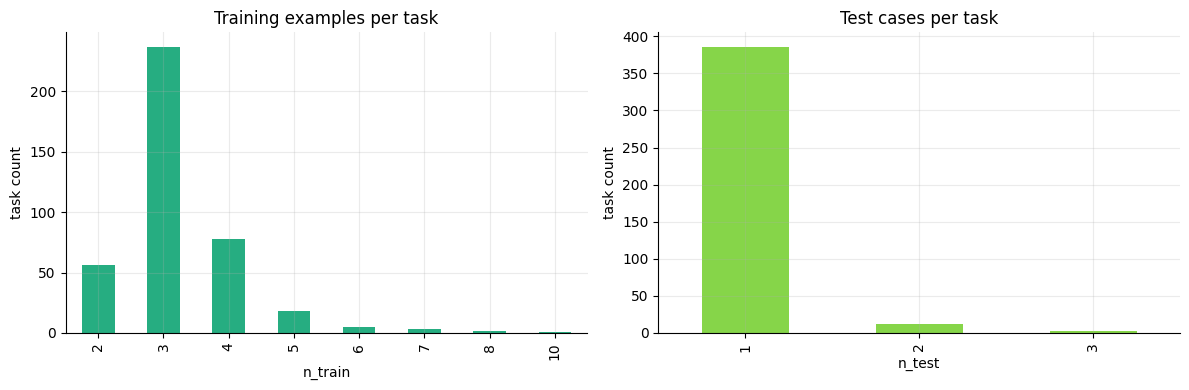

In [6]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    summary_df["n_train"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=plt.get_cmap(PLOT_CMAP)(0.62))
    axes[0].set_title("Training examples per task")
    axes[0].set_xlabel("n_train")
    axes[0].set_ylabel("task count")

    summary_df["n_test"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=plt.get_cmap(PLOT_CMAP)(0.82))
    axes[1].set_title("Test cases per task")
    axes[1].set_xlabel("n_test")
    axes[1].set_ylabel("task count")
    plt.tight_layout()

    train_mode = summary_df["n_train"].mode().iloc[0]
    test_mode = summary_df["n_test"].mode().iloc[0]
    pair_bullets = [
        f"The most common evidence pattern is {train_mode} training examples and {test_mode} test cases.",
        f"Training example counts range from {summary_df['n_train'].min():,} to {summary_df['n_train'].max():,}; prioritize robust validation on the low-example end.",
        f"Test case counts range from {summary_df['n_test'].min():,} to {summary_df['n_test'].max():,}, so export logic should support multiple test inputs per task.",
    ]
else:
    pair_bullets = ["Pair distributions are unavailable until tasks are loaded."]
insight("Pair Distribution Insights", pair_bullets)


## 3.2 Grid Geometry

Grid geometry affects solver design and ONNX cost. Same-shape tasks often suit masking or recoloring logic, while shape-changing tasks need resize, crop, tile, object extraction, or construction strategies.

,task_id,n_train,n_test,has_test_outputs,input_shapes,output_shapes,train_output_shapes,n_input_colors,n_output_colors,input_colors,output_colors,shape_changes_in_train,max_input_area,max_output_area
53,task054,3,1,True,"[(30, 30)]","[(30, 30)]","[(30, 30)]",7,7,"(1, 2, 3, 4, 5, 6, 8)","(1, 2, 3, 4, 5, 6, 8)",False,900,900
73,task074,4,1,True,"[(30, 30)]","[(30, 30)]","[(30, 30)]",10,9,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","(0, 1, 2, 3, 4, 5, 6, 7, 8)",False,900,900
254,task255,3,1,True,"[(30, 30)]","[(30, 30)]","[(30, 30)]",5,6,"(0, 1, 2, 4, 8)","(0, 1, 2, 3, 4, 8)",False,900,900
284,task285,3,1,True,"[(14, 14), (20, 20), (24, 24), (30, 30)]","[(14, 14), (20, 20), (24, 24), (30, 30)]","[(14, 14), (20, 20), (30, 30)]",8,8,"(0, 1, 2, 3, 4, 6, 7, 8)","(0, 1, 2, 3, 4, 6, 7, 8)",False,900,900
348,task349,4,1,True,"[(10, 10), (15, 15), (20, 20), (30, 30)]","[(10, 10), (15, 15), (20, 20), (30, 30)]","[(10, 10), (15, 15), (20, 20)]",2,4,"(0, 9)","(0, 1, 3, 9)",False,900,900
35,task036,2,1,True,"[(30, 30)]","[(3, 3), (4, 4), (5, 3)]","[(3, 3), (5, 3)]",7,4,"(0, 1, 2, 3, 4, 5, 8)","(0, 2, 3, 4)",True,900,16
79,task080,3,1,True,"[(24, 24), (27, 27), (29, 29)]","[(24, 24), (27, 27), (29, 29)]","[(24, 24), (27, 27)]",6,6,"(0, 2, 3, 4, 6, 8)","(0, 2, 3, 4, 6, 8)",False,841,841
109,task110,3,1,True,"[(29, 29)]","[(29, 29)]","[(29, 29)]",10,9,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","(1, 2, 3, 4, 5, 6, 7, 8, 9)",False,841,841
197,task198,3,1,True,"[(19, 19), (24, 24), (27, 27), (29, 29)]","[(19, 19), (24, 24), (27, 27), (29, 29)]","[(19, 19), (24, 24), (29, 29)]",5,6,"(0, 1, 5, 8, 9)","(1, 3, 4, 5, 8, 9)",False,841,841
184,task185,4,1,True,"[(27, 27), (29, 29)]","[(3, 3)]","[(3, 3)]",7,7,"(0, 1, 2, 3, 4, 6, 8)","(0, 1, 2, 3, 4, 6, 8)",True,841,9


### Grid Geometry Insights
- Input area ranges from 5 to 900 cells; output area ranges from 1 to 900 cells.
- Shape-changing tasks account for 34.5% of loaded tasks and should be handled as a distinct solver family.
- The largest-grid tasks listed above are useful stress tests for ONNX cost and memory assumptions.

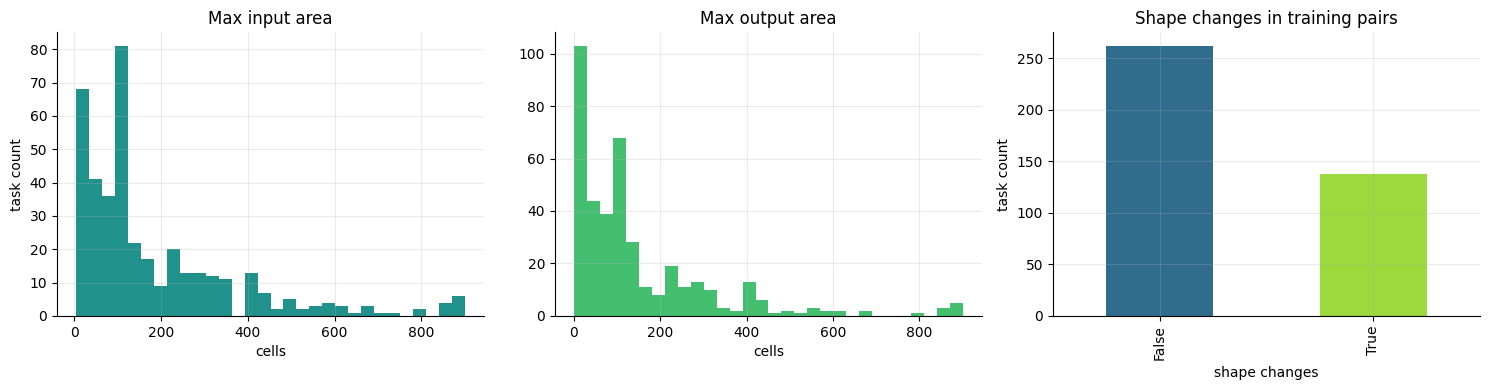

In [7]:
if not summary_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    summary_df["max_input_area"].hist(ax=axes[0], bins=30, color=plt.get_cmap(PLOT_CMAP)(0.50))
    axes[0].set_title("Max input area")
    axes[0].set_xlabel("cells")
    axes[0].set_ylabel("task count")

    summary_df["max_output_area"].hist(ax=axes[1], bins=30, color=plt.get_cmap(PLOT_CMAP)(0.70))
    axes[1].set_title("Max output area")
    axes[1].set_xlabel("cells")

    summary_df["shape_changes_in_train"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color=[plt.get_cmap(PLOT_CMAP)(0.35), plt.get_cmap(PLOT_CMAP)(0.85)])
    axes[2].set_title("Shape changes in training pairs")
    axes[2].set_xlabel("shape changes")
    axes[2].set_ylabel("task count")
    plt.tight_layout()

    largest_tasks = summary_df.sort_values(["max_input_area", "max_output_area"], ascending=False).head(15)
    display(largest_tasks)

    geometry_bullets = [
        f"Input area ranges from {summary_df['max_input_area'].min():,} to {summary_df['max_input_area'].max():,} cells; output area ranges from {summary_df['max_output_area'].min():,} to {summary_df['max_output_area'].max():,} cells.",
        f"Shape-changing tasks account for {summary_df['shape_changes_in_train'].mean():.1%} of loaded tasks and should be handled as a distinct solver family.",
        f"The largest-grid tasks listed above are useful stress tests for ONNX cost and memory assumptions.",
    ]
else:
    geometry_bullets = ["Grid geometry cannot be summarized until tasks are loaded."]
insight("Grid Geometry Insights", geometry_bullets)


## 3.3 Color Usage

ARC colors are discrete symbols rather than natural-image colors. Frequency and palette-size checks help identify tasks that may be solved by color mapping, background handling, object masks, or simple token substitutions.

,color,train_input_cells,train_output_cells
0,0,110888,74925
1,1,13121,11270
2,2,9909,10046
3,3,9140,11237
4,4,6740,6879
5,5,8784,6552
6,6,3738,3482
7,7,2344,2339
8,8,12208,9439
9,9,2008,1419


### Color Usage Insights
- Color 0 is the most frequent training-input token; color 0 is the most frequent training-output token.
- Palette size ranges from 1 to 10 unique input colors per task.
- Compare input versus output frequencies to spot colors commonly introduced, removed, or used as background.

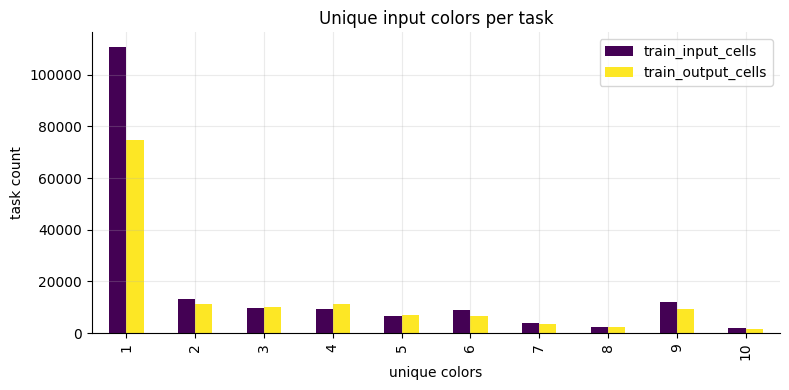

In [8]:
def count_grid_values(tasks: dict[str, dict[str, Any]], split: str, field: str) -> Counter:
    counts: Counter = Counter()
    for task in tasks.values():
        for pair in task.get(split, []):
            if field in pair:
                counts.update(np.asarray(pair[field]).ravel().astype(int).tolist())
    return counts


train_input_color_counts = count_grid_values(tasks, "train", "input")
train_output_color_counts = count_grid_values(tasks, "train", "output")

color_df = pd.DataFrame({
    "color": range(10),
    "train_input_cells": [train_input_color_counts.get(i, 0) for i in range(10)],
    "train_output_cells": [train_output_color_counts.get(i, 0) for i in range(10)],
})
display(color_df)

if not color_df.empty:
    ax = color_df.set_index("color")[["train_input_cells", "train_output_cells"]].plot(kind="bar", figsize=(10, 4), colormap=PLOT_CMAP)
    ax.set_title("ARC token frequency in training pairs")
    ax.set_xlabel("ARC color token")
    ax.set_ylabel("cell count")
    plt.tight_layout()

if not summary_df.empty:
    ax = summary_df["n_input_colors"].value_counts().sort_index().plot(kind="bar", figsize=(8, 4), color=plt.get_cmap(PLOT_CMAP)(0.68))
    ax.set_title("Unique input colors per task")
    ax.set_xlabel("unique colors")
    ax.set_ylabel("task count")
    plt.tight_layout()

    dominant_input = int(color_df.sort_values("train_input_cells", ascending=False).iloc[0]["color"])
    dominant_output = int(color_df.sort_values("train_output_cells", ascending=False).iloc[0]["color"])
    color_bullets = [
        f"Color {dominant_input} is the most frequent training-input token; color {dominant_output} is the most frequent training-output token.",
        f"Palette size ranges from {summary_df['n_input_colors'].min():,} to {summary_df['n_input_colors'].max():,} unique input colors per task.",
        "Compare input versus output frequencies to spot colors commonly introduced, removed, or used as background.",
    ]
else:
    color_bullets = ["Color usage cannot be interpreted until tasks are loaded."]
insight("Color Usage Insights", color_bullets)


## 3.4 Structural Deep Dive

This diagnostic separates tasks by output-shape behavior, area expansion/compression, and multiple-test-case risk. These features are useful for deciding whether a baseline can be task-constant, same-shape, or needs input-conditioned logic.

In [9]:
if not summary_df.empty:
    deep_df = summary_df.copy()
    deep_df["area_delta"] = deep_df["max_output_area"] - deep_df["max_input_area"]
    deep_df["area_ratio"] = np.where(deep_df["max_input_area"] > 0, deep_df["max_output_area"] / deep_df["max_input_area"], np.nan)
    deep_df["test_case_group"] = np.where(deep_df["n_test"] == 1, "single test case", "multiple test cases")
    deep_df["area_group"] = pd.cut(
        deep_df["area_ratio"],
        bins=[-np.inf, 0.5, 0.95, 1.05, 2.0, np.inf],
        labels=["strong compression", "mild compression", "same area", "mild expansion", "strong expansion"],
    )

    structural_table = pd.crosstab(deep_df["area_group"], deep_df["shape_changes_in_train"], margins=True)
    test_table = deep_df["test_case_group"].value_counts().rename_axis("test_case_group").reset_index(name="task_count")
    display(structural_table)
    display(test_table)
    display(deep_df.sort_values("area_ratio", ascending=False).head(10)[["task_id", "n_train", "n_test", "input_shapes", "output_shapes", "area_ratio", "area_group"]])
    display(deep_df.sort_values("area_ratio", ascending=True).head(10)[["task_id", "n_train", "n_test", "input_shapes", "output_shapes", "area_ratio", "area_group"]])

    single_test_share = (deep_df["n_test"] == 1).mean()
    same_area_share = (deep_df["area_group"] == "same area").mean()
    structural_bullets = [
        f"{single_test_share:.1%} of tasks have exactly one test case, which makes a constant-output ONNX sanity baseline practical for most tasks.",
        f"{same_area_share:.1%} of tasks preserve approximate max area, but area preservation does not guarantee same-shape behavior.",
        "Strong expansion and strong compression tasks should be reviewed separately because they usually require construction, extraction, tiling, or cropping logic rather than simple recoloring.",
    ]
else:
    structural_bullets = ["Structural deep dive requires loaded task summaries."]
insight("Structural Deep Dive Insights", structural_bullets)


shape_changes_in_train,False,True,All
area_group,,,
strong compression,0,97,97
mild compression,0,5,5
same area,262,0,262
mild expansion,0,10,10
strong expansion,0,26,26
All,262,138,400


,test_case_group,task_count
0,single test case,386
1,multiple test cases,14


,task_id,n_train,n_test,input_shapes,output_shapes,area_ratio,area_group
397,task398,5,1,"[(1, 5)]","[(5, 5), (10, 10), (15, 15), (20, 20)]",80.0,strong expansion
220,task221,4,1,"[(3, 3)]","[(9, 9), (12, 12), (15, 15), (18, 18), (21, 21)]",49.0,strong expansion
268,task269,3,1,"[(3, 3)]","[(6, 6), (9, 9), (12, 12), (15, 15)]",25.0,strong expansion
106,task107,3,1,"[(5, 5)]","[(10, 10), (15, 15), (20, 20), (25, 25)]",25.0,strong expansion
288,task289,5,1,"[(3, 3)]","[(6, 6), (9, 9), (12, 12)]",16.0,strong expansion
222,task223,2,1,"[(3, 3)]","[(9, 9)]",9.0,strong expansion
314,task315,3,1,"[(3, 3)]","[(9, 9)]",9.0,strong expansion
303,task304,3,1,"[(3, 3)]","[(9, 9)]",9.0,strong expansion
103,task104,2,1,"[(3, 3)]","[(9, 9)]",9.0,strong expansion
0,task001,5,1,"[(3, 3)]","[(9, 9)]",9.0,strong expansion


,task_id,n_train,n_test,input_shapes,output_shapes,area_ratio,area_group
354,task355,4,1,"[(16, 15), (16, 17), (16, 19), (17, 13), (18, 19)]","[(1, 1)]",0.002924,strong compression
290,task291,3,1,"[(14, 15), (15, 13), (15, 17), (16, 17)]","[(1, 1)]",0.003676,strong compression
345,task346,4,1,"[(5, 9), (7, 9), (11, 9), (11, 12), (12, 12)]","[(1, 1)]",0.006944,strong compression
184,task185,4,1,"[(27, 27), (29, 29)]","[(3, 3)]",0.010702,strong compression
183,task184,3,1,"[(18, 22), (20, 20), (23, 17), (23, 28)]","[(2, 2), (2, 3), (3, 2), (3, 3)]",0.013975,strong compression
390,task391,4,1,"[(13, 10), (13, 13), (13, 16), (15, 13)]","[(3, 1)]",0.014423,strong compression
133,task134,3,1,"[(20, 24), (22, 23), (22, 26), (24, 23)]","[(3, 3)]",0.015734,strong compression
35,task036,2,1,"[(30, 30)]","[(3, 3), (4, 4), (5, 3)]",0.017778,strong compression
114,task115,3,1,"[(9, 7), (11, 9), (14, 14), (14, 16)]","[(1, 3), (1, 4), (3, 1), (4, 1)]",0.017857,strong compression
217,task218,3,1,"[(21, 21)]","[(2, 2), (3, 2), (3, 3)]",0.020408,strong compression


### Structural Deep Dive Insights
- 96.5% of tasks have exactly one test case, which makes a constant-output ONNX sanity baseline practical for most tasks.
- 65.5% of tasks preserve approximate max area, but area preservation does not guarantee same-shape behavior.
- Strong expansion and strong compression tasks should be reviewed separately because they usually require construction, extraction, tiling, or cropping logic rather than simple recoloring.

## 3.5 Color Delta Deep Dive

Color set differences between inputs and outputs reveal tasks that introduce new tokens, remove tokens, or preserve the same palette while changing geometry or layout.

,palette_relation,task_count
0,same palette,176
1,removes colors,91
2,introduces colors,86
3,introduces and removes colors,47


,task_id,input_colors,output_colors,introduced_colors,removed_colors,shape_changes_in_train
1,task002,"(0, 3)","(0, 3, 4)","(4,)",(),False
2,task003,"(0, 1)","(0, 2)","(2,)","(1,)",True
5,task006,"(0, 1, 5)","(0, 2)","(2,)","(1, 5)",True
6,task007,"(0, 1, 2, 3, 4, 8)","(1, 2, 3, 4, 8)",(),"(0,)",False
9,task010,"(0, 5)","(0, 1, 2, 3, 4)","(1, 2, 3, 4)","(5,)",False
10,task011,"(0, 2, 3, 4, 5, 6, 8)","(0, 2, 3, 4, 5, 6)",(),"(8,)",False
13,task014,"(0, 1, 2, 3, 4, 8)","(0, 1, 2, 3, 4)",(),"(8,)",True
14,task015,"(0, 1, 2, 6, 8)","(0, 1, 2, 4, 6, 7, 8)","(4, 7)",(),False
16,task017,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","(1, 2, 3, 4, 5, 6, 7, 8, 9)",(),"(0,)",False
18,task019,"(0, 2, 3, 4, 5, 6)","(0, 2, 3, 4, 5, 6, 8)","(8,)",(),True


### Color Delta Insights
- 44.0% of tasks preserve the same observed input/output color set, making geometry and object logic more important than new-color prediction for those tasks.
- Tasks that introduce colors are good candidates for rule families involving marking, filling, completion, or derived labels.
- Tasks that remove colors often indicate masking, filtering, object selection, or background normalization.

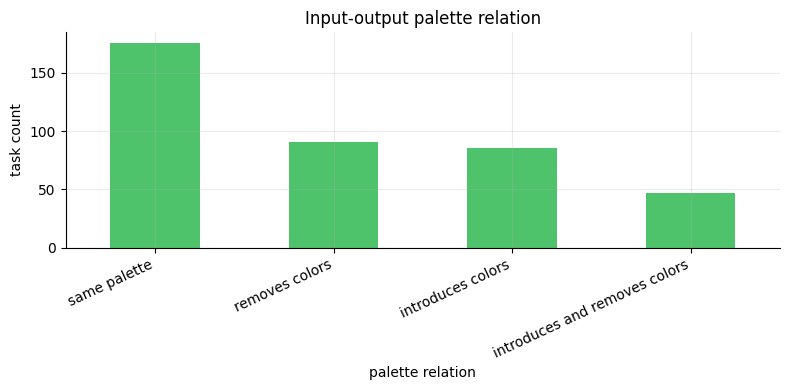

In [10]:
if not summary_df.empty:
    color_delta_df = summary_df.copy()
    color_delta_df["introduced_colors"] = color_delta_df.apply(lambda row: tuple(sorted(set(row["output_colors"]) - set(row["input_colors"]))), axis=1)
    color_delta_df["removed_colors"] = color_delta_df.apply(lambda row: tuple(sorted(set(row["input_colors"]) - set(row["output_colors"]))), axis=1)
    color_delta_df["palette_relation"] = np.select(
        [
            color_delta_df["introduced_colors"].map(len).eq(0) & color_delta_df["removed_colors"].map(len).eq(0),
            color_delta_df["introduced_colors"].map(len).gt(0) & color_delta_df["removed_colors"].map(len).eq(0),
            color_delta_df["introduced_colors"].map(len).eq(0) & color_delta_df["removed_colors"].map(len).gt(0),
        ],
        ["same palette", "introduces colors", "removes colors"],
        default="introduces and removes colors",
    )

    palette_table = color_delta_df["palette_relation"].value_counts().rename_axis("palette_relation").reset_index(name="task_count")
    display(palette_table)
    display(color_delta_df.query("palette_relation != 'same palette'").head(20)[["task_id", "input_colors", "output_colors", "introduced_colors", "removed_colors", "shape_changes_in_train"]])

    ax = palette_table.set_index("palette_relation")["task_count"].plot(kind="bar", figsize=(8, 4), color=plt.get_cmap(PLOT_CMAP)(0.72))
    ax.set_title("Input-output palette relation")
    ax.set_xlabel("palette relation")
    ax.set_ylabel("task count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    same_palette_share = (color_delta_df["palette_relation"] == "same palette").mean()
    color_delta_bullets = [
        f"{same_palette_share:.1%} of tasks preserve the same observed input/output color set, making geometry and object logic more important than new-color prediction for those tasks.",
        "Tasks that introduce colors are good candidates for rule families involving marking, filling, completion, or derived labels.",
        "Tasks that remove colors often indicate masking, filtering, object selection, or background normalization.",
    ]
else:
    color_delta_bullets = ["Color delta analysis requires loaded task summaries."]
insight("Color Delta Insights", color_delta_bullets)


# 4. Task Review

## 4.1 Visual Inspection Tools

Manual inspection remains essential for ARC-style transformations. The helper below renders train and test examples consistently, while gracefully handling missing test outputs.

### Visual Inspection Insights
- The first loaded task, `task001`, is rendered as a smoke test for the visualization helper.
- Use this view to identify object movement, color replacement, cropping, symmetry, tiling, or counting transformations before implementing solver logic.

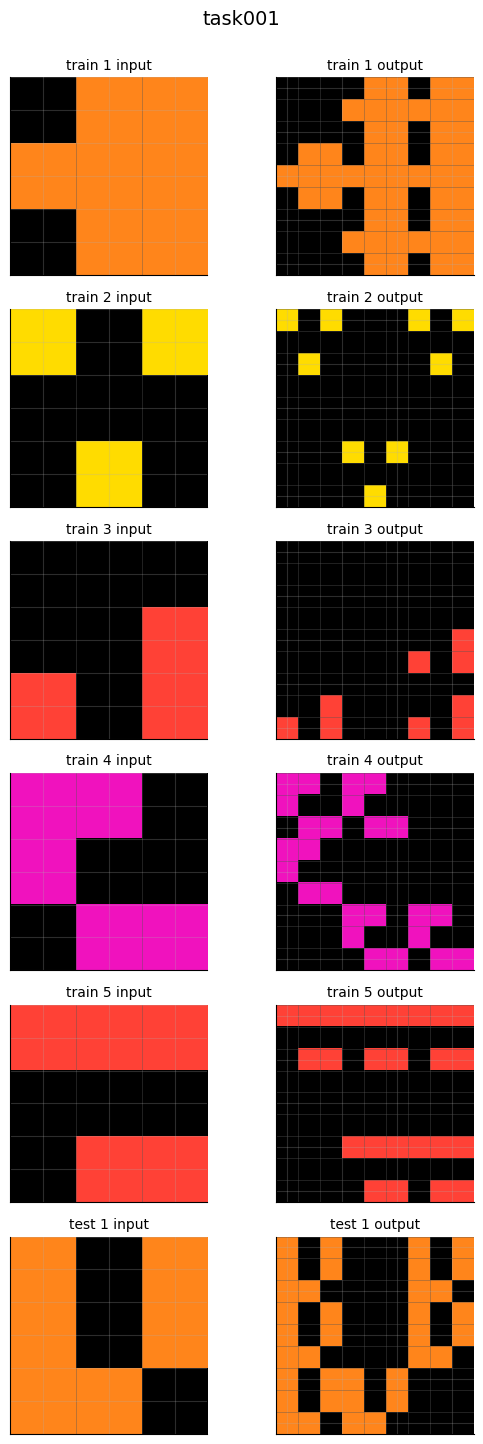

In [11]:
def show_grid(ax: plt.Axes, grid: list[list[int]], title: str) -> None:
    arr = np.asarray(grid)
    ax.imshow(arr, cmap=ARC_CMAP, norm=ARC_NORM)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(-0.5, arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, arr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#555555", linewidth=0.5, alpha=0.55)
    ax.tick_params(which="both", left=False, bottom=False, labelleft=False, labelbottom=False)


def show_task(task_id: str, max_pairs: int | None = None) -> None:
    task = tasks[task_id]
    rows: list[tuple[str, int, dict[str, Any]]] = []
    for split in ["train", "test"]:
        pairs = task.get(split, [])
        if max_pairs is not None:
            pairs = pairs[:max_pairs]
        rows.extend((split, idx, pair) for idx, pair in enumerate(pairs, start=1))

    n_rows = len(rows)
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, max(2.2, 2.4 * n_rows)))
    axes = np.asarray(axes).reshape(n_rows, n_cols)
    fig.suptitle(task_id, fontsize=14, y=1.0)

    for row_idx, (split, idx, pair) in enumerate(rows):
        show_grid(axes[row_idx, 0], pair["input"], f"{split} {idx} input")
        if "output" in pair:
            show_grid(axes[row_idx, 1], pair["output"], f"{split} {idx} output")
        else:
            axes[row_idx, 1].axis("off")
            axes[row_idx, 1].set_title(f"{split} {idx} output unavailable", fontsize=10)
    plt.tight_layout()


if tasks:
    first_task_id = next(iter(tasks))
    show_task(first_task_id)
    visual_bullets = [
        f"The first loaded task, `{first_task_id}`, is rendered as a smoke test for the visualization helper.",
        "Use this view to identify object movement, color replacement, cropping, symmetry, tiling, or counting transformations before implementing solver logic.",
    ]
else:
    visual_bullets = ["Visual inspection requires loaded tasks."]
insight("Visual Inspection Insights", visual_bullets)


## 4.2 Diverse Task Samples

The sample set intentionally mixes large grids, many-color tasks, shape-changing tasks, and compact same-shape tasks. This makes browsing more representative than simply looking at the first few task ids.

In [12]:
sample_ids: list[str] = []
if not summary_df.empty:
    sample_ids.extend(summary_df.sort_values("max_input_area", ascending=False).head(2)["task_id"].tolist())
    sample_ids.extend(summary_df.sort_values("n_input_colors", ascending=False).head(2)["task_id"].tolist())
    sample_ids.extend(summary_df.query("shape_changes_in_train == True").head(2)["task_id"].tolist())
    sample_ids.extend(summary_df.query("shape_changes_in_train == False").sort_values("max_input_area").head(2)["task_id"].tolist())

sample_ids = list(dict.fromkeys(sample_ids))
display(sample_ids)

insight(
    "Sampling Insights",
    [
        f"Selected {len(sample_ids):,} diverse tasks for visual review.",
        "After running on Kaggle, inspect these examples before deciding whether solver buckets need to be refined.",
    ],
)


['task349',
 'task054',
 'task354',
 'task068',
 'task001',
 'task003',
 'task053',
 'task087']

### Sampling Insights
- Selected 8 diverse tasks for visual review.
- After running on Kaggle, inspect these examples before deciding whether solver buckets need to be refined.

### Manual Review Notes
- Look for repeated transformation motifs across sampled tasks, then convert those motifs into explicit solver families.
- Flag tasks whose outputs cannot be explained by same-shape recoloring, object extraction, or simple geometric construction.

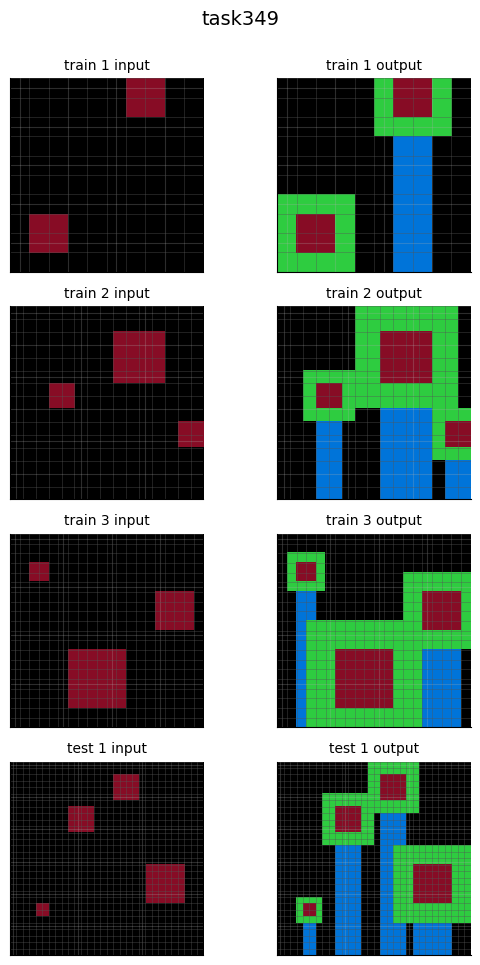

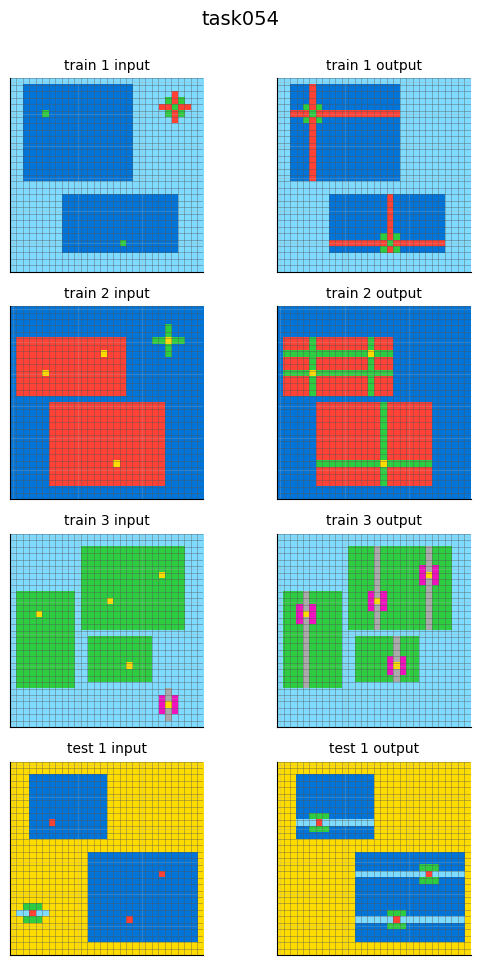

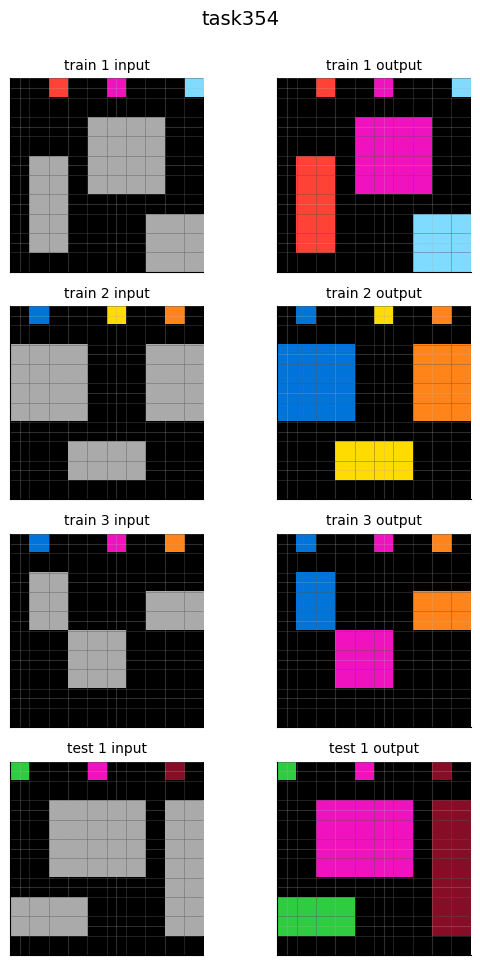

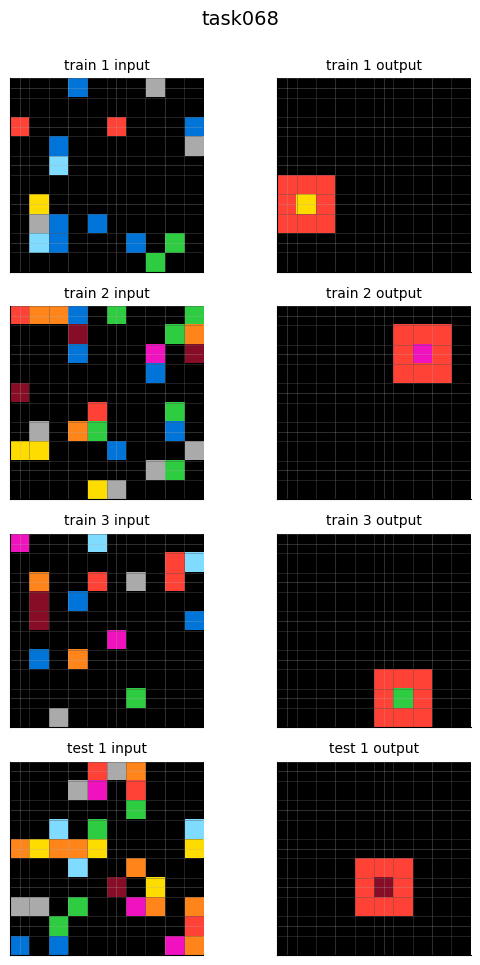

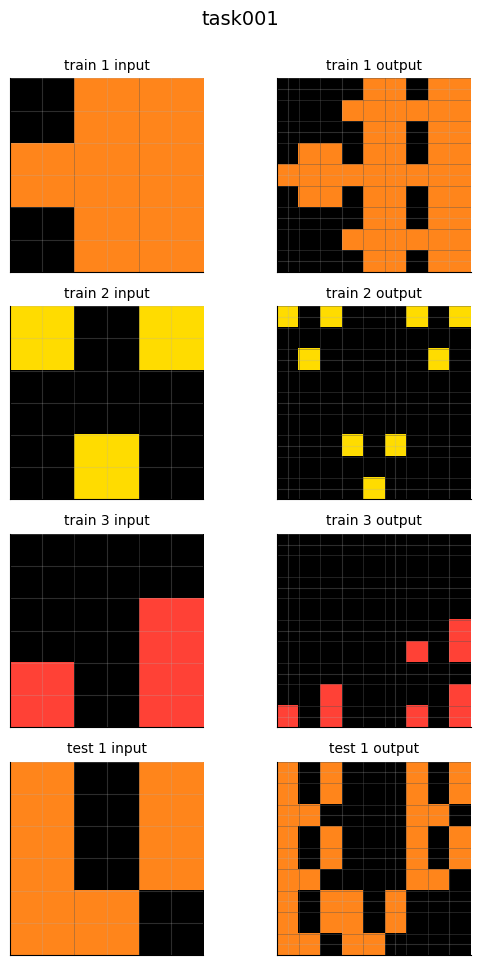

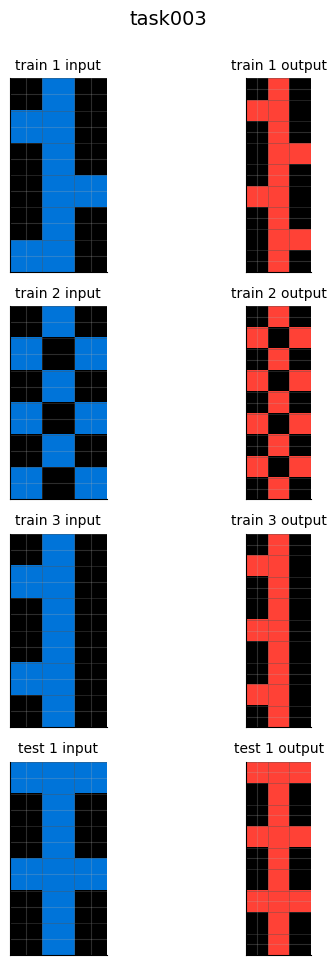

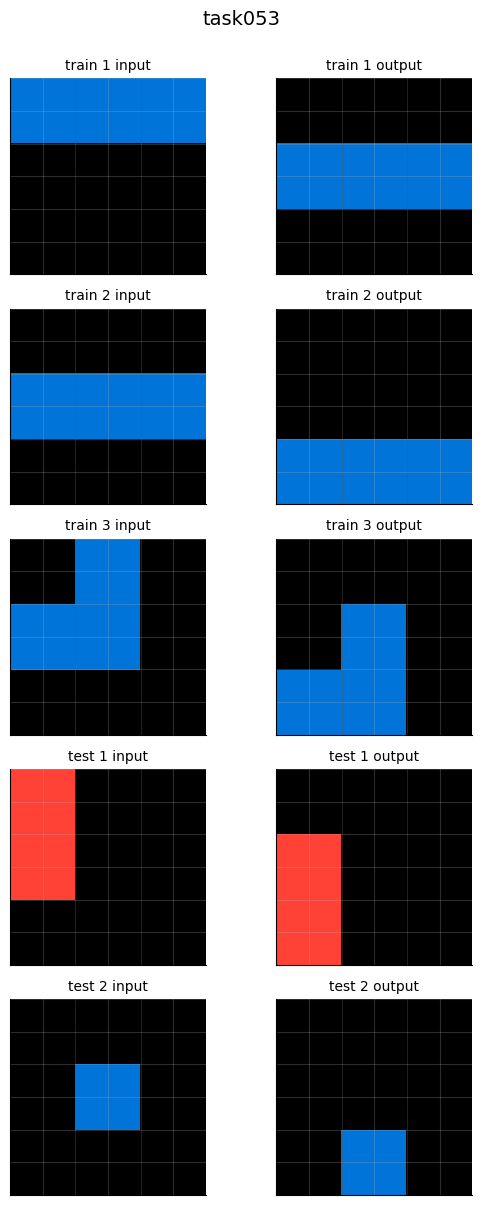

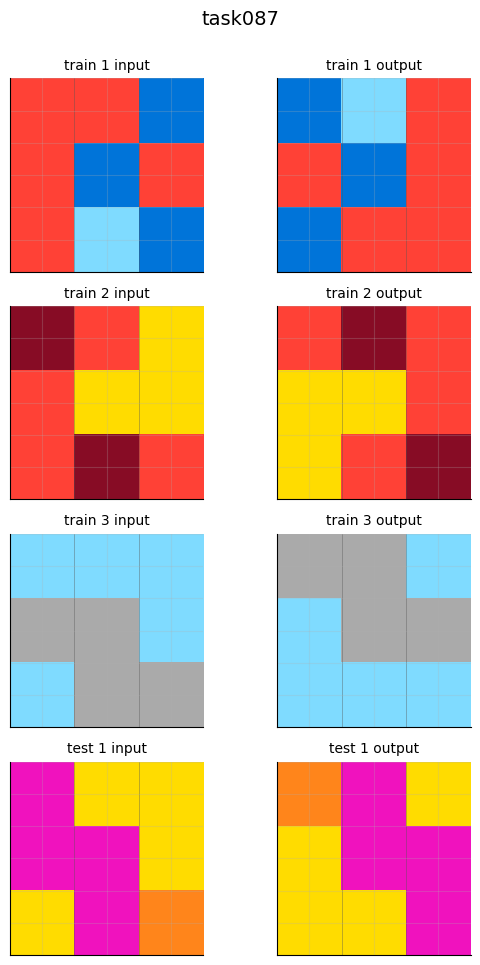

In [13]:
for task_id in sample_ids[:8]:
    show_task(task_id, max_pairs=3)

insight(
    "Manual Review Notes",
    [
        "Look for repeated transformation motifs across sampled tasks, then convert those motifs into explicit solver families.",
        "Flag tasks whose outputs cannot be explained by same-shape recoloring, object extraction, or simple geometric construction.",
    ] if sample_ids else ["No sampled tasks are available yet."],
)


# 5. Planning and Artifacts

## 5.1 Baseline Feasibility

Before building solver families, estimate what a submission-format sanity baseline can cover. This is not meant to be the final modeling approach; it checks how much of the dataset can be packaged with simple ONNX output behavior.

In [14]:
if not summary_df.empty:
    baseline_df = summary_df.copy()
    baseline_df["constant_output_feasible"] = baseline_df["n_test"].eq(1) & baseline_df["has_test_outputs"]
    feasibility_table = baseline_df[["constant_output_feasible", "shape_changes_in_train"]].value_counts().rename_axis(["constant_output_feasible", "shape_changes_in_train"]).reset_index(name="task_count")
    display(feasibility_table)

    feasible_count = int(baseline_df["constant_output_feasible"].sum())
    feasibility_bullets = [
        f"A constant-output ONNX packaging baseline can cover {feasible_count:,} / {len(baseline_df):,} tasks if test outputs are available and each task has one test case.",
        "Multiple-test-case tasks need either input-conditioned selection or a real transformation solver; they should be isolated early in the baseline notebook.",
        "The first baseline should validate file naming, ONNX input/output names, tensor dtypes, zip creation, and optional onnxruntime checks before solver complexity grows.",
    ]
else:
    feasibility_bullets = ["Baseline feasibility requires loaded task summaries."]
insight("Baseline Feasibility Insights", feasibility_bullets)


,constant_output_feasible,shape_changes_in_train,task_count
0,True,False,256
1,True,True,130
2,False,True,8
3,False,False,6


### Baseline Feasibility Insights
- A constant-output ONNX packaging baseline can cover 386 / 400 tasks if test outputs are available and each task has one test case.
- Multiple-test-case tasks need either input-conditioned selection or a real transformation solver; they should be isolated early in the baseline notebook.
- The first baseline should validate file naming, ONNX input/output names, tensor dtypes, zip creation, and optional onnxruntime checks before solver complexity grows.

## 5.2 Solver Planning Buckets

These buckets are deliberately simple. They create a practical bridge from EDA to later solver notebooks, where each bucket can be replaced by measured solver diagnostics and ONNX export checks.

,bucket,task_count
0,shape-changing,138
1,larger same-shape,108
2,small same-shape,85
3,low-color same-shape,69


,task_id,n_train,n_test,has_test_outputs,input_shapes,output_shapes,train_output_shapes,n_input_colors,n_output_colors,input_colors,output_colors,shape_changes_in_train,max_input_area,max_output_area,eda_bucket
0,task001,5,1,True,"[(3, 3)]","[(9, 9)]","[(9, 9)]",5,5,"(0, 2, 4, 6, 7)","(0, 2, 4, 6, 7)",True,9,81,shape-changing
1,task002,5,1,True,"[(6, 6), (10, 10), (20, 20)]","[(6, 6), (10, 10), (20, 20)]","[(6, 6), (10, 10), (20, 20)]",2,3,"(0, 3)","(0, 3, 4)",False,400,400,low-color same-shape
2,task003,3,1,True,"[(6, 3)]","[(9, 3)]","[(9, 3)]",2,2,"(0, 1)","(0, 2)",True,18,27,shape-changing
3,task004,2,1,True,"[(8, 9), (10, 10), (14, 9)]","[(8, 9), (10, 10), (14, 9)]","[(8, 9), (14, 9)]",5,5,"(0, 2, 4, 6, 8)","(0, 2, 4, 6, 8)",False,126,126,larger same-shape
4,task005,3,1,True,"[(21, 21)]","[(21, 21)]","[(21, 21)]",8,8,"(0, 1, 2, 3, 4, 5, 6, 8)","(0, 1, 2, 3, 4, 5, 6, 8)",False,441,441,larger same-shape


### Solver Planning Insights
- The largest provisional bucket is `shape-changing` with 138 tasks.
- Treat same-shape and shape-changing tasks as separate implementation tracks in the next notebook.
- Use bucket-level pass rates later to decide which solver families deserve ONNX optimization effort.

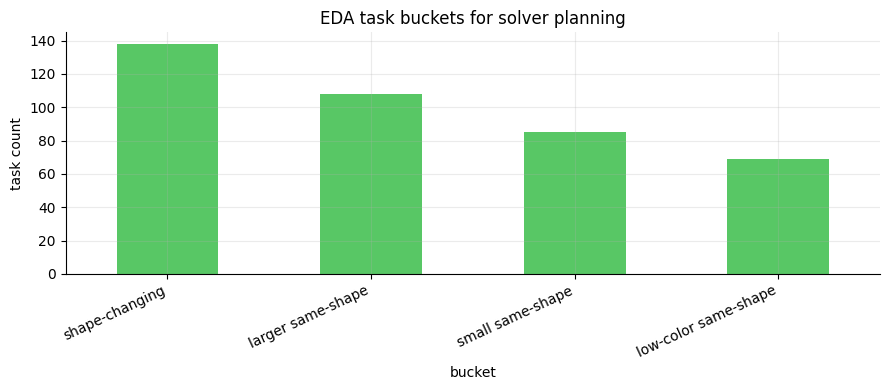

In [15]:
def assign_bucket(row: pd.Series) -> str:
    if row["shape_changes_in_train"]:
        return "shape-changing"
    if row["n_input_colors"] <= 2:
        return "low-color same-shape"
    if row["max_input_area"] <= 100:
        return "small same-shape"
    return "larger same-shape"


if not summary_df.empty:
    summary_df = summary_df.copy()
    summary_df["eda_bucket"] = summary_df.apply(assign_bucket, axis=1)
    bucket_df = summary_df["eda_bucket"].value_counts().rename_axis("bucket").reset_index(name="task_count")
    display(bucket_df)

    ax = summary_df["eda_bucket"].value_counts().plot(kind="bar", figsize=(9, 4), color=plt.get_cmap(PLOT_CMAP)(0.74))
    ax.set_title("EDA task buckets for solver planning")
    ax.set_xlabel("bucket")
    ax.set_ylabel("task count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    display(summary_df.head())
    leading_bucket = bucket_df.iloc[0]
    bucket_bullets = [
        f"The largest provisional bucket is `{leading_bucket['bucket']}` with {int(leading_bucket['task_count']):,} tasks.",
        "Treat same-shape and shape-changing tasks as separate implementation tracks in the next notebook.",
        "Use bucket-level pass rates later to decide which solver families deserve ONNX optimization effort.",
    ]
else:
    bucket_bullets = ["Solver buckets cannot be assigned until task summaries are available."]
insight("Solver Planning Insights", bucket_bullets)


## 5.3 Export EDA Artifacts

The final cell writes compact CSV summaries under `/kaggle/working` on Kaggle. These artifacts keep later notebooks lightweight and provide a stable reference for solver planning.

In [16]:
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
if not summary_df.empty:
    summary_path = OUTPUT_DIR / "neurogolf_eda_task_summary.csv"
    color_path = OUTPUT_DIR / "neurogolf_eda_color_counts.csv"
    summary_df.to_csv(summary_path, index=False)
    color_df.to_csv(color_path, index=False)
    print(f"Wrote {summary_path}")
    print(f"Wrote {color_path}")
    export_bullets = [
        f"Saved task-level features to `{summary_path}`.",
        f"Saved color-token counts to `{color_path}`.",
        "Attach these CSVs to downstream Kaggle notebooks when iterating on solver experiments.",
    ]
else:
    export_bullets = ["No CSV artifacts were written because no task summaries are available."]
insight("Export Insights", export_bullets)


Wrote /kaggle/working/neurogolf_eda_task_summary.csv
Wrote /kaggle/working/neurogolf_eda_color_counts.csv


### Export Insights
- Saved task-level features to `/kaggle/working/neurogolf_eda_task_summary.csv`.
- Saved color-token counts to `/kaggle/working/neurogolf_eda_color_counts.csv`.
- Attach these CSVs to downstream Kaggle notebooks when iterating on solver experiments.